# AGIQA-3K: Perceptual Quality Assessment for AI-Generated Images
## Exploratory Data Analysis & Visualization
> **Dataset:** AGIQA-3K (2,982 images, 6 generative models)  
> **Targets:** MOS Perception & MOS Alignment  
> **Course:** Image Processing and Computer Vision (7323)

## 0. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import cv2
from PIL import Image
import os
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.facecolor':  'white',
    'axes.facecolor':    '#f8f9fa',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
})
PAL = ['#4361ee','#f72585','#7209b7','#3a0ca3','#4cc9f0','#f77f00','#06d6a0']

# ── Paths — UPDATE THESE ────────────────────────────────────────────────────
CSV_PATH   = 'data.csv'          # path to data.csv
IMAGE_DIR  = 'AGIQA-3K/'        # path to image folder (optional for EDA)
OUT_DIR    = 'figures/'
os.makedirs(OUT_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load & Inspect the Dataset

In [2]:
df = pd.read_csv(CSV_PATH, header=None, names=[
    'image_name', 'prompt', 'adj1', 'adj2', 'style',
    'mos_p', 'std_p', 'mos_a', 'std_a'
])

# Drop header row if present
def is_numeric(x):
    try: float(x); return True
    except: return False

if not is_numeric(df['mos_p'].iloc[0]):
    df = df.iloc[1:].reset_index(drop=True)

# Cast score columns
for col in ['mos_p', 'std_p', 'mos_a', 'std_a']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Extract model name from filename  e.g. 'glide_0001.jpg' → 'glide'
df['model'] = df['image_name'].str.extract(r'^([a-zA-Z_]+?)[\ d_]')[0].str.lower().str.strip('_')

print(f'Shape: {df.shape}')
print(f'Models: {sorted(df["model"].dropna().unique())}')
df.head()

Shape: (2982, 10)
Models: ['attngan', 'gli', 'mi', 's']


,image_name,prompt,adj1,adj2,style,mos_p,std_p,mos_a,std_a,model
0,AttnGAN_normal_000.jpg,statue of a man,NaN,NaN,NaN,0.965603,0.223270,0.408893,0.615608,attngan
1,AttnGAN_normal_001.jpg,a tray of sushi,NaN,NaN,NaN,1.361853,0.645422,0.428797,0.667071,attngan
2,AttnGAN_normal_002.jpg,man lost in space,NaN,NaN,NaN,0.195283,0.949403,0.506802,0.723514,attngan
3,AttnGAN_normal_003.jpg,a cosmic universe,NaN,NaN,NaN,1.075006,0.256997,0.207691,0.461926,attngan
4,AttnGAN_normal_004.jpg,red and blue armor,NaN,NaN,NaN,1.391763,1.019677,0.564245,0.719811,attngan


In [3]:
# Quick summary
print('=== Score Columns Summary ===')
df[['mos_p','std_p','mos_a','std_a']].describe().round(4)

=== Score Columns Summary ===


,mos_p,std_p,mos_a,std_a
count,2982.0000,2982.0000,2982.0000,2982.0000
mean,2.5004,0.5997,2.5000,0.7411
std,0.9979,0.2133,0.9990,0.2712
min,0.0000,0.1083,0.0215,0.1087
25%,1.7924,0.4451,1.9210,0.5370
50%,2.7344,0.5792,2.7985,0.7064
75%,3.2625,0.7306,3.2391,0.9083
max,4.4887,1.4523,4.2862,1.9335


In [4]:
print('Missing values:')
print(df.isnull().sum())
print(f'\nImages per model:')
print(df['model'].value_counts())

Missing values:
image_name       0
prompt           0
adj1          1190
adj2          2188
style         1587
mos_p            0
std_p            0
mos_a            0
std_a            0
model          590
dtype: int64

Images per model:
model
s          1200
mi          592
attngan     300
gli         300
Name: count, dtype: int64


## 2. MOS Score Distributions

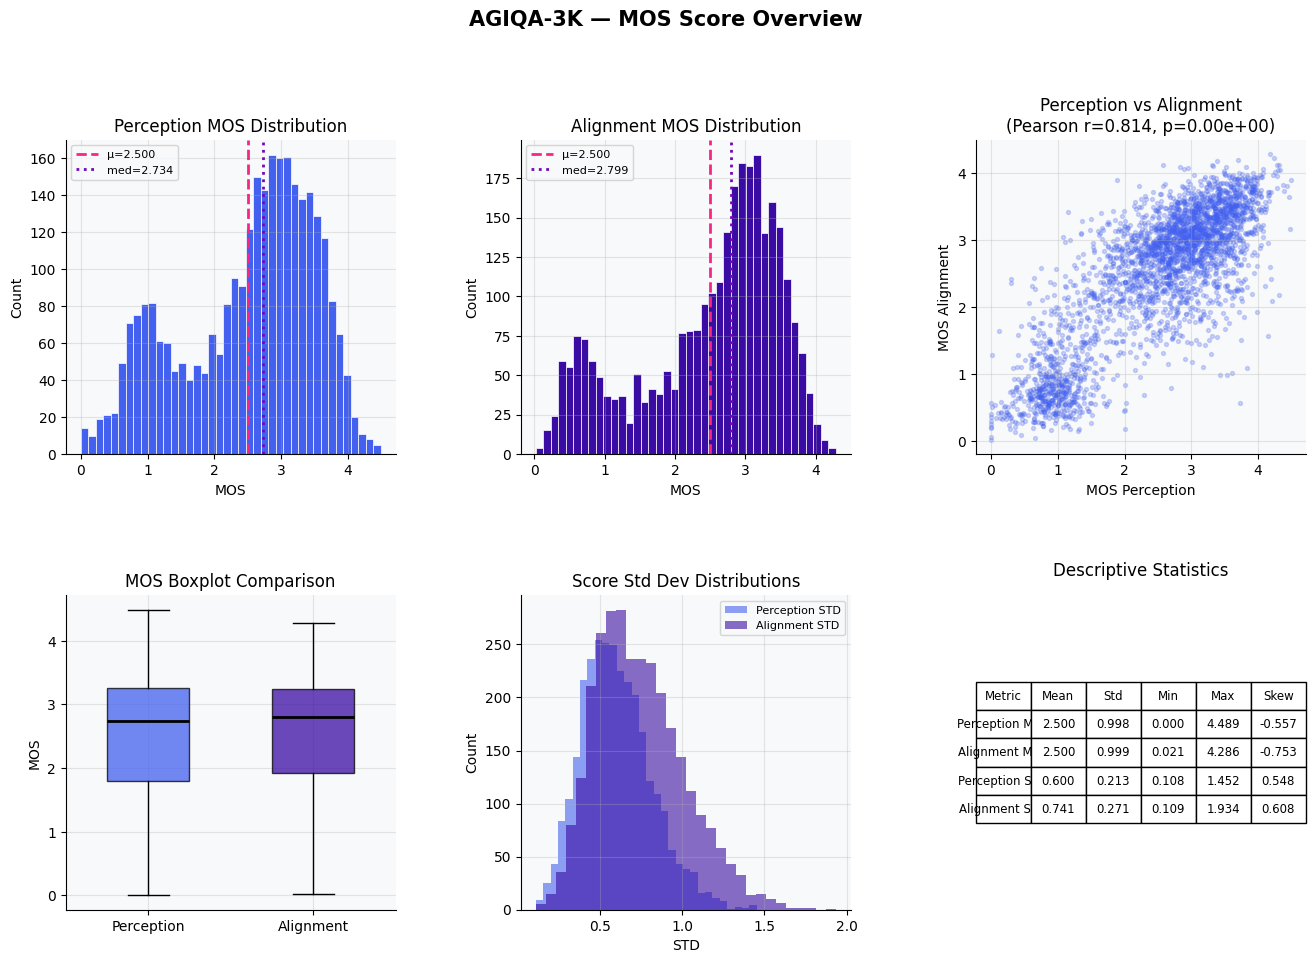

In [5]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('AGIQA-3K — MOS Score Overview', fontsize=15, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# 2a — Perception MOS histogram
ax = fig.add_subplot(gs[0, 0])
ax.hist(df['mos_p'].dropna(), bins=40, color=PAL[0], edgecolor='white', lw=0.5)
ax.axvline(df['mos_p'].mean(),   color=PAL[1], ls='--', lw=2, label=f"μ={df['mos_p'].mean():.3f}")
ax.axvline(df['mos_p'].median(), color=PAL[2], ls=':',  lw=2, label=f"med={df['mos_p'].median():.3f}")
ax.set_xlabel('MOS'); ax.set_ylabel('Count')
ax.set_title('Perception MOS Distribution'); ax.legend(fontsize=8)

# 2b — Alignment MOS histogram
ax = fig.add_subplot(gs[0, 1])
ax.hist(df['mos_a'].dropna(), bins=40, color=PAL[3], edgecolor='white', lw=0.5)
ax.axvline(df['mos_a'].mean(),   color=PAL[1], ls='--', lw=2, label=f"μ={df['mos_a'].mean():.3f}")
ax.axvline(df['mos_a'].median(), color=PAL[2], ls=':',  lw=2, label=f"med={df['mos_a'].median():.3f}")
ax.set_xlabel('MOS'); ax.set_ylabel('Count')
ax.set_title('Alignment MOS Distribution'); ax.legend(fontsize=8)

# 2c — Perception vs Alignment scatter
ax = fig.add_subplot(gs[0, 2])
ax.scatter(df['mos_p'], df['mos_a'], alpha=0.25, s=8, c=PAL[0])
r, p = stats.pearsonr(df['mos_p'].dropna(), df['mos_a'].dropna())
ax.set_xlabel('MOS Perception'); ax.set_ylabel('MOS Alignment')
ax.set_title(f'Perception vs Alignment\n(Pearson r={r:.3f}, p={p:.2e})')

# 2d — Box plots
ax = fig.add_subplot(gs[1, 0])
bp = ax.boxplot([df['mos_p'].dropna(), df['mos_a'].dropna()],
                patch_artist=True, widths=0.5,
                medianprops=dict(color='black', lw=2))
for patch, c in zip(bp['boxes'], [PAL[0], PAL[3]]):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.set_xticklabels(['Perception', 'Alignment'])
ax.set_ylabel('MOS'); ax.set_title('MOS Boxplot Comparison')

# 2e — STD distributions
ax = fig.add_subplot(gs[1, 1])
ax.hist(df['std_p'].dropna(), bins=30, color=PAL[0], alpha=0.6, label='Perception STD')
ax.hist(df['std_a'].dropna(), bins=30, color=PAL[3], alpha=0.6, label='Alignment STD')
ax.set_xlabel('STD'); ax.set_ylabel('Count')
ax.set_title('Score Std Dev Distributions'); ax.legend(fontsize=8)

# 2f — Descriptive stats table
ax = fig.add_subplot(gs[1, 2]); ax.axis('off')
rows = []
for col, label in [('mos_p','Perception MOS'),('mos_a','Alignment MOS'),
                    ('std_p','Perception STD'),('std_a','Alignment STD')]:
    s = df[col].dropna()
    rows.append([label, f'{s.mean():.3f}', f'{s.std():.3f}',
                 f'{s.min():.3f}', f'{s.max():.3f}', f'{s.skew():.3f}'])
tbl = ax.table(cellText=rows,
               colLabels=['Metric','Mean','Std','Min','Max','Skew'],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1, 1.7)
ax.set_title('Descriptive Statistics', pad=14)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig1_mos_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Per-Model MOS Analysis

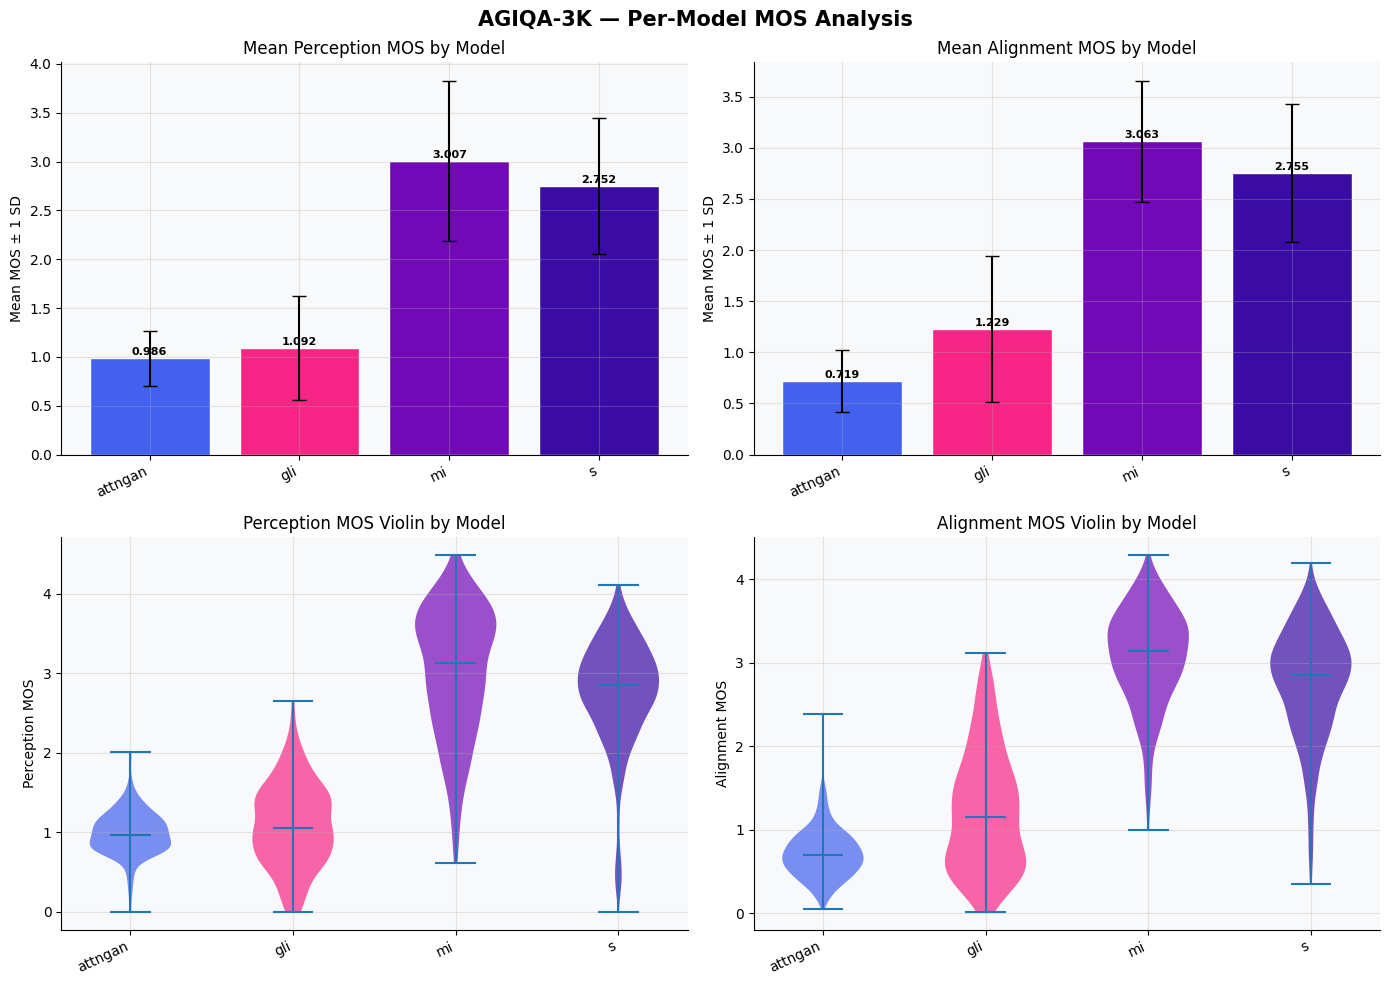

In [6]:
models = sorted(df['model'].dropna().unique())
n = len(models)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('AGIQA-3K — Per-Model MOS Analysis', fontsize=15, fontweight='bold')

# 3a — Mean perception MOS
ax = axes[0, 0]
means_p = df.groupby('model')['mos_p'].mean().reindex(models)
stds_p  = df.groupby('model')['mos_p'].std().reindex(models)
bars = ax.bar(models, means_p, yerr=stds_p, color=PAL[:n], edgecolor='white',
              capsize=5, error_kw=dict(lw=1.5))
for b, v in zip(bars, means_p):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylabel('Mean MOS ± 1 SD')
ax.set_title('Mean Perception MOS by Model')
ax.set_xticklabels(models, rotation=25, ha='right')

# 3b — Mean alignment MOS
ax = axes[0, 1]
means_a = df.groupby('model')['mos_a'].mean().reindex(models)
stds_a  = df.groupby('model')['mos_a'].std().reindex(models)
bars = ax.bar(models, means_a, yerr=stds_a, color=PAL[:n], edgecolor='white',
              capsize=5, error_kw=dict(lw=1.5))
for b, v in zip(bars, means_a):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
            f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylabel('Mean MOS ± 1 SD')
ax.set_title('Mean Alignment MOS by Model')
ax.set_xticklabels(models, rotation=25, ha='right')

# 3c — Violin perception
ax = axes[1, 0]
data_vp = [df[df['model']==m]['mos_p'].dropna().values for m in models]
vp = ax.violinplot(data_vp, positions=range(n), showmedians=True)
for body, c in zip(vp['bodies'], PAL):
    body.set_facecolor(c); body.set_alpha(0.7)
ax.set_xticks(range(n)); ax.set_xticklabels(models, rotation=25, ha='right')
ax.set_ylabel('Perception MOS')
ax.set_title('Perception MOS Violin by Model')

# 3d — Violin alignment
ax = axes[1, 1]
data_va = [df[df['model']==m]['mos_a'].dropna().values for m in models]
va = ax.violinplot(data_va, positions=range(n), showmedians=True)
for body, c in zip(va['bodies'], PAL):
    body.set_facecolor(c); body.set_alpha(0.7)
ax.set_xticks(range(n)); ax.set_xticklabels(models, rotation=25, ha='right')
ax.set_ylabel('Alignment MOS')
ax.set_title('Alignment MOS Violin by Model')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig2_per_model.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Style & Adjective Analysis

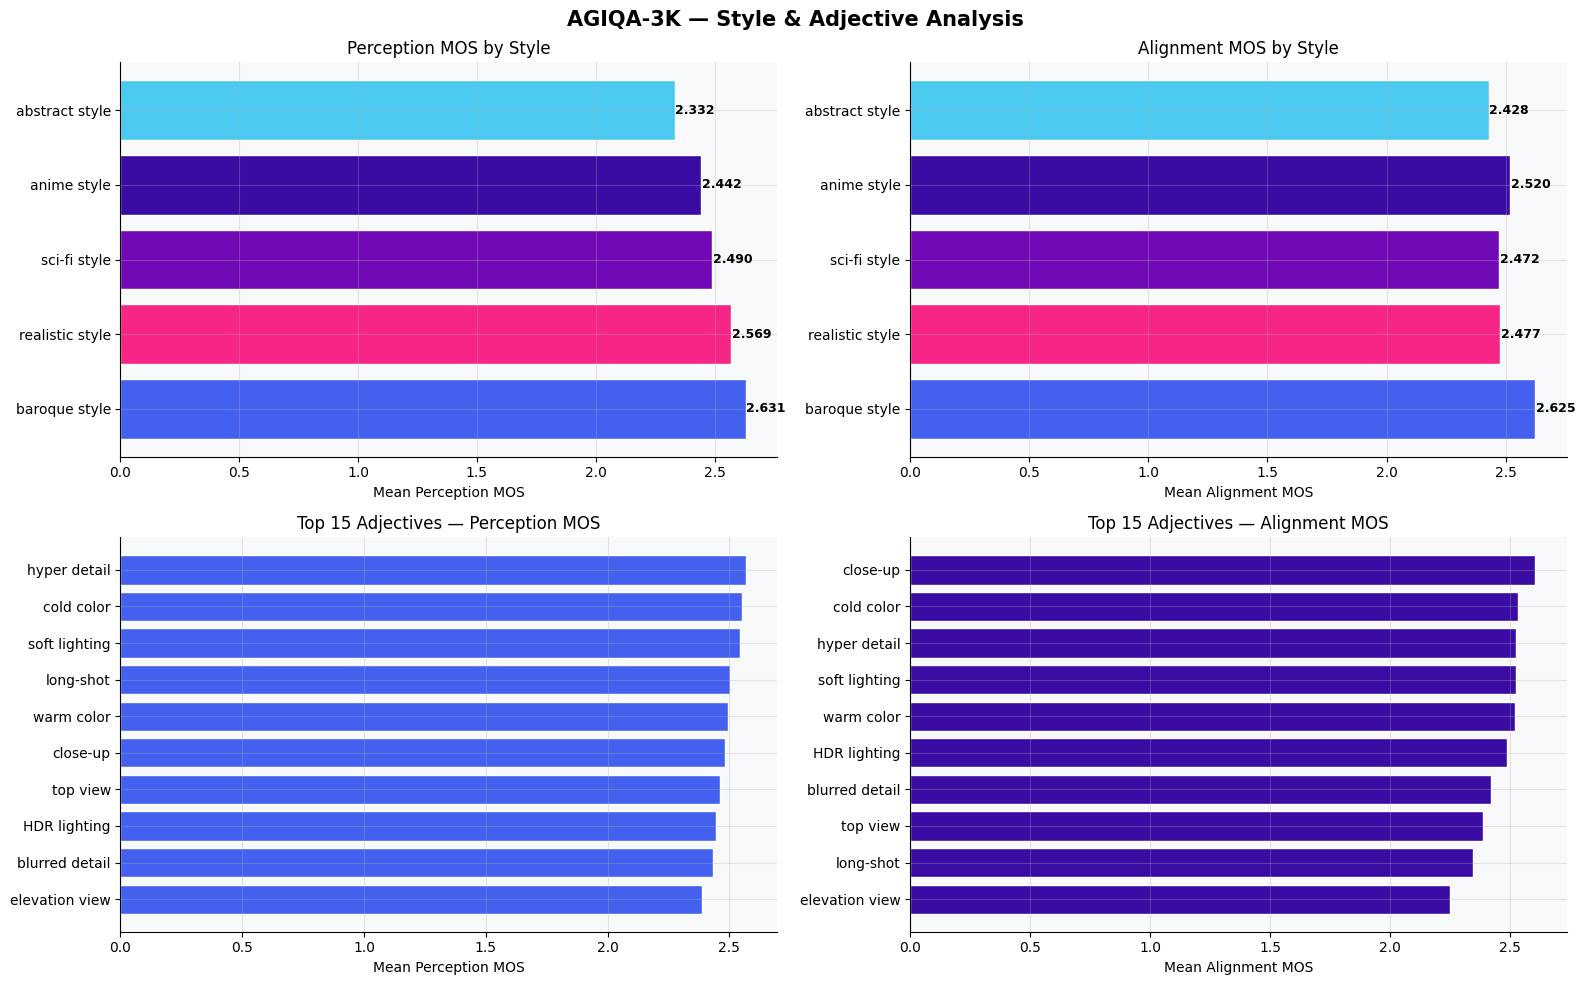

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('AGIQA-3K — Style & Adjective Analysis', fontsize=15, fontweight='bold')

# 4a — Perception MOS by style
ax = axes[0, 0]
style_p = df.groupby('style')['mos_p'].mean().sort_values(ascending=False)
styles  = style_p.index.tolist()
bars = ax.barh(styles, style_p.values,
               color=[PAL[i%len(PAL)] for i in range(len(styles))], edgecolor='white')
for b, v in zip(bars, style_p.values):
    ax.text(v+0.003, b.get_y()+b.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Mean Perception MOS'); ax.set_title('Perception MOS by Style')

# 4b — Alignment MOS by style
ax = axes[0, 1]
style_a = df.groupby('style')['mos_a'].mean().reindex(styles)
bars = ax.barh(styles, style_a.values,
               color=[PAL[i%len(PAL)] for i in range(len(styles))], edgecolor='white')
for b, v in zip(bars, style_a.values):
    ax.text(v+0.003, b.get_y()+b.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Mean Alignment MOS'); ax.set_title('Alignment MOS by Style')

# 4c — Top adjectives by perception MOS
ax = axes[1, 0]
all_adj_p = pd.concat([
    df[['adj1','mos_p']].rename(columns={'adj1':'adj'}),
    df[['adj2','mos_p']].rename(columns={'adj2':'adj'})
])
adj_means_p = all_adj_p.groupby('adj')['mos_p'].mean().sort_values(ascending=False).head(15)
ax.barh(adj_means_p.index[::-1], adj_means_p.values[::-1],
        color=PAL[0], edgecolor='white')
ax.set_xlabel('Mean Perception MOS')
ax.set_title('Top 15 Adjectives — Perception MOS')

# 4d — Top adjectives by alignment MOS
ax = axes[1, 1]
all_adj_a = pd.concat([
    df[['adj1','mos_a']].rename(columns={'adj1':'adj'}),
    df[['adj2','mos_a']].rename(columns={'adj2':'adj'})
])
adj_means_a = all_adj_a.groupby('adj')['mos_a'].mean().sort_values(ascending=False).head(15)
ax.barh(adj_means_a.index[::-1], adj_means_a.values[::-1],
        color=PAL[3], edgecolor='white')
ax.set_xlabel('Mean Alignment MOS')
ax.set_title('Top 15 Adjectives — Alignment MOS')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig3_style_adj.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Model × Style MOS Heatmaps

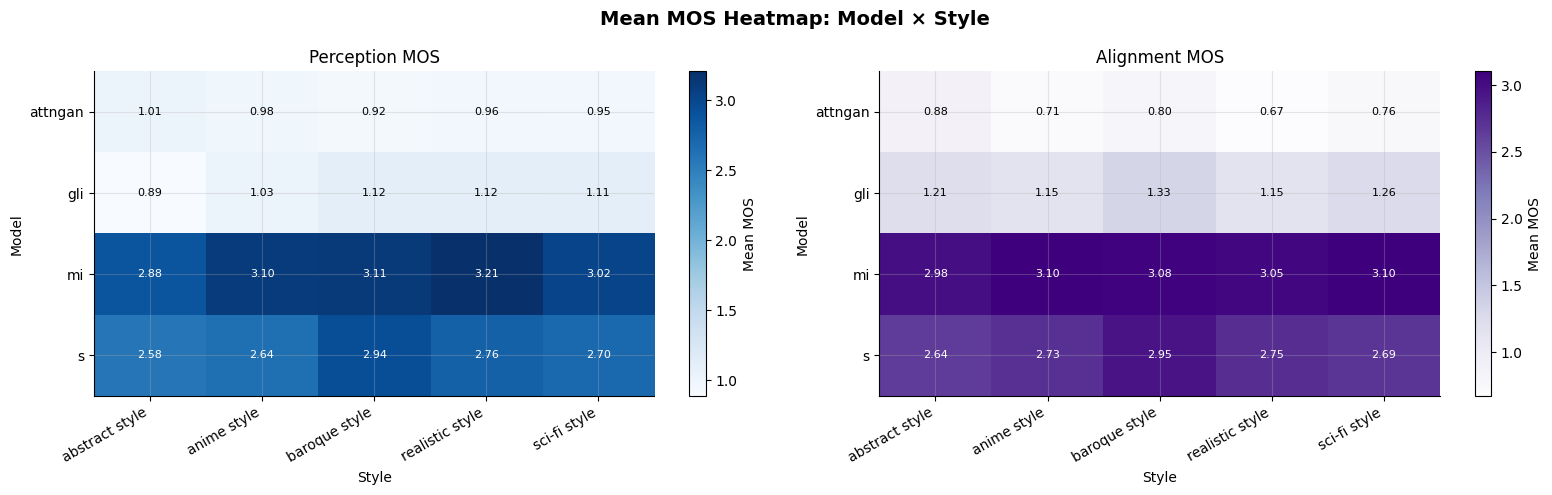

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Mean MOS Heatmap: Model × Style', fontsize=14, fontweight='bold')

for ax, col, title, cmap in zip(
    axes,
    ['mos_p', 'mos_a'],
    ['Perception MOS', 'Alignment MOS'],
    ['Blues', 'Purples']
):
    pivot = df.pivot_table(values=col, index='model', columns='style', aggfunc='mean')
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto')
    plt.colorbar(im, ax=ax, label='Mean MOS')
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index)
    # Annotate cells
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=8, color='white' if val > pivot.values.mean() else 'black')
    ax.set_title(title); ax.set_xlabel('Style'); ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig4_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Score Reliability & Correlation Analysis

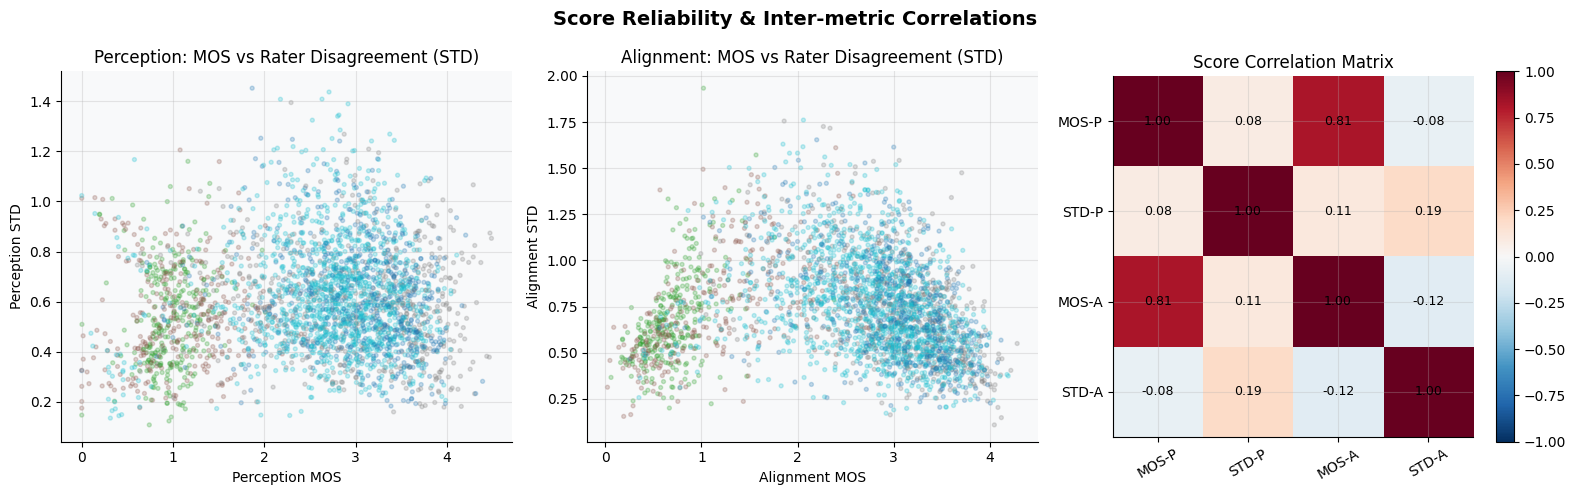

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Score Reliability & Inter-metric Correlations', fontsize=14, fontweight='bold')

# 6a — MOS vs STD for perception (reliability)
ax = axes[0]
sc = ax.scatter(df['mos_p'], df['std_p'], alpha=0.25, s=8,
                c=df['model'].astype('category').cat.codes, cmap='tab10')
ax.set_xlabel('Perception MOS'); ax.set_ylabel('Perception STD')
ax.set_title('Perception: MOS vs Rater Disagreement (STD)')

# 6b — MOS vs STD for alignment
ax = axes[1]
ax.scatter(df['mos_a'], df['std_a'], alpha=0.25, s=8,
           c=df['model'].astype('category').cat.codes, cmap='tab10')
ax.set_xlabel('Alignment MOS'); ax.set_ylabel('Alignment STD')
ax.set_title('Alignment: MOS vs Rater Disagreement (STD)')

# 6c — Correlation matrix of all 4 score columns
ax = axes[2]
corr_mat = df[['mos_p','std_p','mos_a','std_a']].corr()
labels = ['MOS-P','STD-P','MOS-A','STD-A']
im = ax.imshow(corr_mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=30)
ax.set_yticks(range(4)); ax.set_yticklabels(labels)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{corr_mat.values[i,j]:.2f}', ha='center', va='center', fontsize=9)
ax.set_title('Score Correlation Matrix')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig5_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Sample Images — Best, Worst, Median Quality

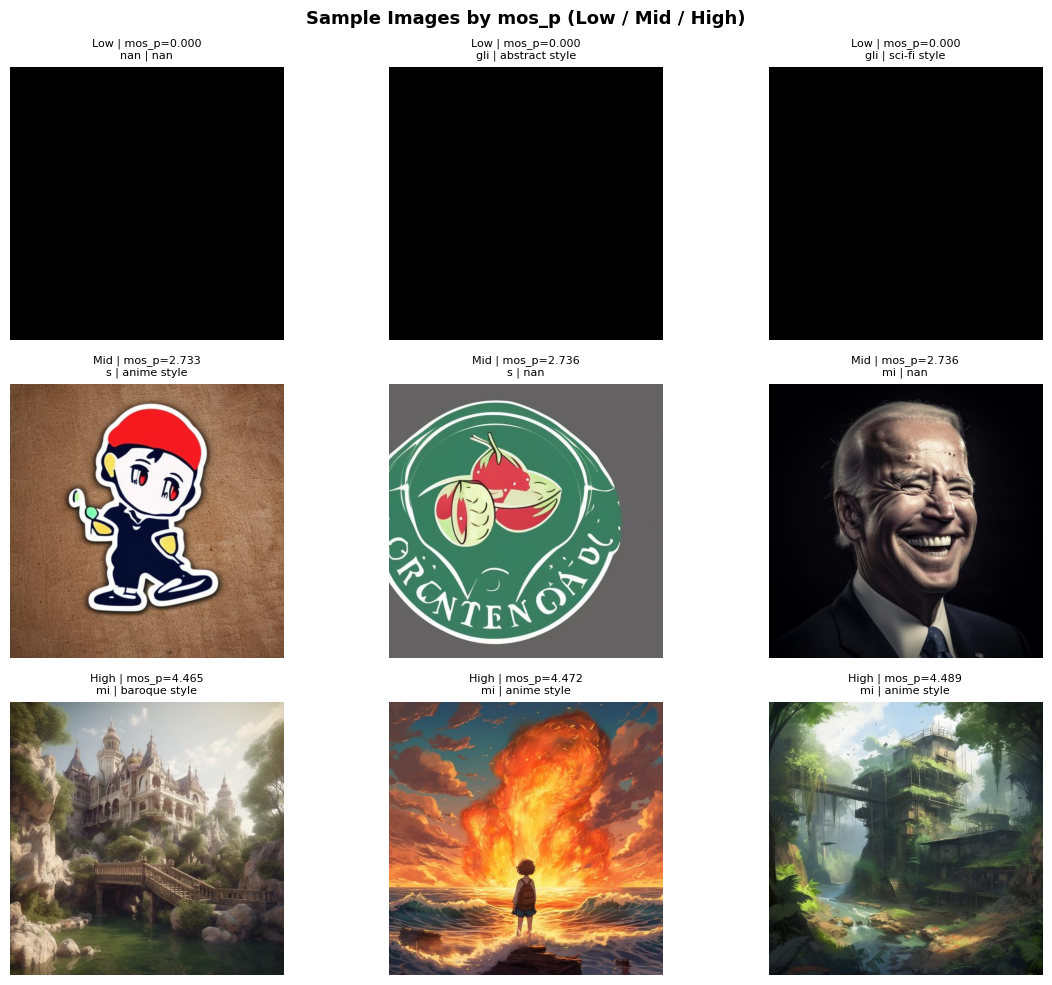

In [10]:
# Shows top-3, bottom-3, and middle-3 images by perception MOS
def show_samples(df, image_dir, col='mos_p', n=3):
    df_s = df.dropna(subset=[col]).sort_values(col)
    idxs = list(df_s.head(n).index) + \
           list(df_s.iloc[len(df_s)//2 - n//2 : len(df_s)//2 + n//2 + 1].index) + \
           list(df_s.tail(n).index)
    labels = ['Low']*n + ['Mid']*n + ['High']*n

    fig, axes = plt.subplots(3, n, figsize=(n*4, 10))
    fig.suptitle(f'Sample Images by {col} (Low / Mid / High)', fontsize=13, fontweight='bold')

    for ax, idx, lbl in zip(axes.flatten(), idxs, labels):
        row = df.loc[idx]
        path = os.path.join(image_dir, row['image_name'])
        if os.path.exists(path):
            img = Image.open(path).convert('RGB')
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'Image\nnot found', ha='center', va='center',
                    transform=ax.transAxes, fontsize=10, color='gray')
        ax.set_title(f"{lbl} | {col}={row[col]:.3f}\n{row['model']} | {row['style']}",
                     fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}fig6_samples.png', dpi=120, bbox_inches='tight')
    plt.show()

if os.path.isdir(IMAGE_DIR):
    show_samples(df, IMAGE_DIR, col='mos_p', n=3)
else:
    print(f'[!] Image directory not found: {IMAGE_DIR}')
    print('    Update IMAGE_DIR at the top and re-run this cell.')

## 8. Image Feature Extraction

> Run this section only if `IMAGE_DIR` is set correctly. Processes up to 600 images and extracts low-level visual features.

In [11]:
FEATURE_NAMES = [
    'sharpness', 'brightness', 'contrast',
    'r_mean', 'g_mean', 'b_mean', 'r_std', 'g_std', 'b_std',
    'colorfulness', 'entropy', 'edge_density', 'saturation',
    'width', 'height', 'aspect_ratio'
]

def extract_one(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None: return None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w    = gray.shape
    r, g, b = img_rgb[:,:,0], img_rgb[:,:,1], img_rgb[:,:,2]
    hist    = cv2.calcHist([gray],[0],None,[256],[0,256]).flatten()
    hist   /= (hist.sum() + 1e-9)
    hsv     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    edges   = cv2.Canny(gray, 100, 200)
    return {
        'sharpness':    cv2.Laplacian(gray, cv2.CV_64F).var(),
        'brightness':   gray.mean(),
        'contrast':     gray.std(),
        'r_mean': r.mean(), 'g_mean': g.mean(), 'b_mean': b.mean(),
        'r_std':  r.std(),  'g_std':  g.std(),  'b_std':  b.std(),
        'colorfulness': np.sqrt((r.mean()-g.mean())**2 + (r.mean()-b.mean())**2 + (g.mean()-b.mean())**2),
        'entropy':      -np.sum(hist * np.log2(hist + 1e-9)),
        'edge_density': edges.mean(),
        'saturation':   hsv[:,:,1].mean(),
        'width': w, 'height': h, 'aspect_ratio': w/h
    }

MAX_IMAGES = 600
records = []
for i, row in df.iterrows():
    if len(records) >= MAX_IMAGES: break
    path = os.path.join(IMAGE_DIR, row['image_name'])
    records.append(extract_one(path) if os.path.exists(path) else None)
    if len(records) % 100 == 0: print(f'  {len(records)} / {MAX_IMAGES}')

feat_df = pd.DataFrame(records)
feat_df.index = df.index[:len(feat_df)]
print(f'Valid: {feat_df.dropna().shape[0]} / {len(feat_df)}')
feat_df.describe().round(3)

  100 / 600
  200 / 600
  300 / 600
  400 / 600
  500 / 600
  600 / 600
Valid: 600 / 600


,sharpness,brightness,contrast,r_mean,g_mean,b_mean,r_std,g_std,b_std,colorfulness,entropy,edge_density,saturation,width,height,aspect_ratio
count,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.000,600.0,600.0,600.0
mean,299.847,105.710,54.460,112.295,104.064,96.882,58.120,56.356,54.833,44.951,6.852,12.602,97.106,512.0,512.0,1.0
std,498.798,43.207,18.046,46.844,45.162,47.041,20.240,19.148,20.089,37.734,1.103,11.577,49.372,0.0,0.0,0.0
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.000,0.000,0.000,512.0,512.0,1.0
25%,43.985,74.452,42.658,79.148,70.942,62.148,45.663,44.084,40.734,17.353,6.683,4.889,58.543,512.0,512.0,1.0
50%,116.785,105.790,54.468,114.037,103.610,90.665,58.097,56.240,54.703,35.718,7.232,9.526,91.095,512.0,512.0,1.0
75%,321.969,133.934,66.025,142.436,134.846,127.659,71.913,69.362,68.818,59.911,7.539,16.847,131.735,512.0,512.0,1.0
max,5062.087,232.076,106.755,240.245,229.874,224.598,114.294,109.946,115.963,247.010,7.937,66.050,244.411,512.0,512.0,1.0


## 9. Feature Correlation with MOS

Merged shape for analysis: (600, 18)


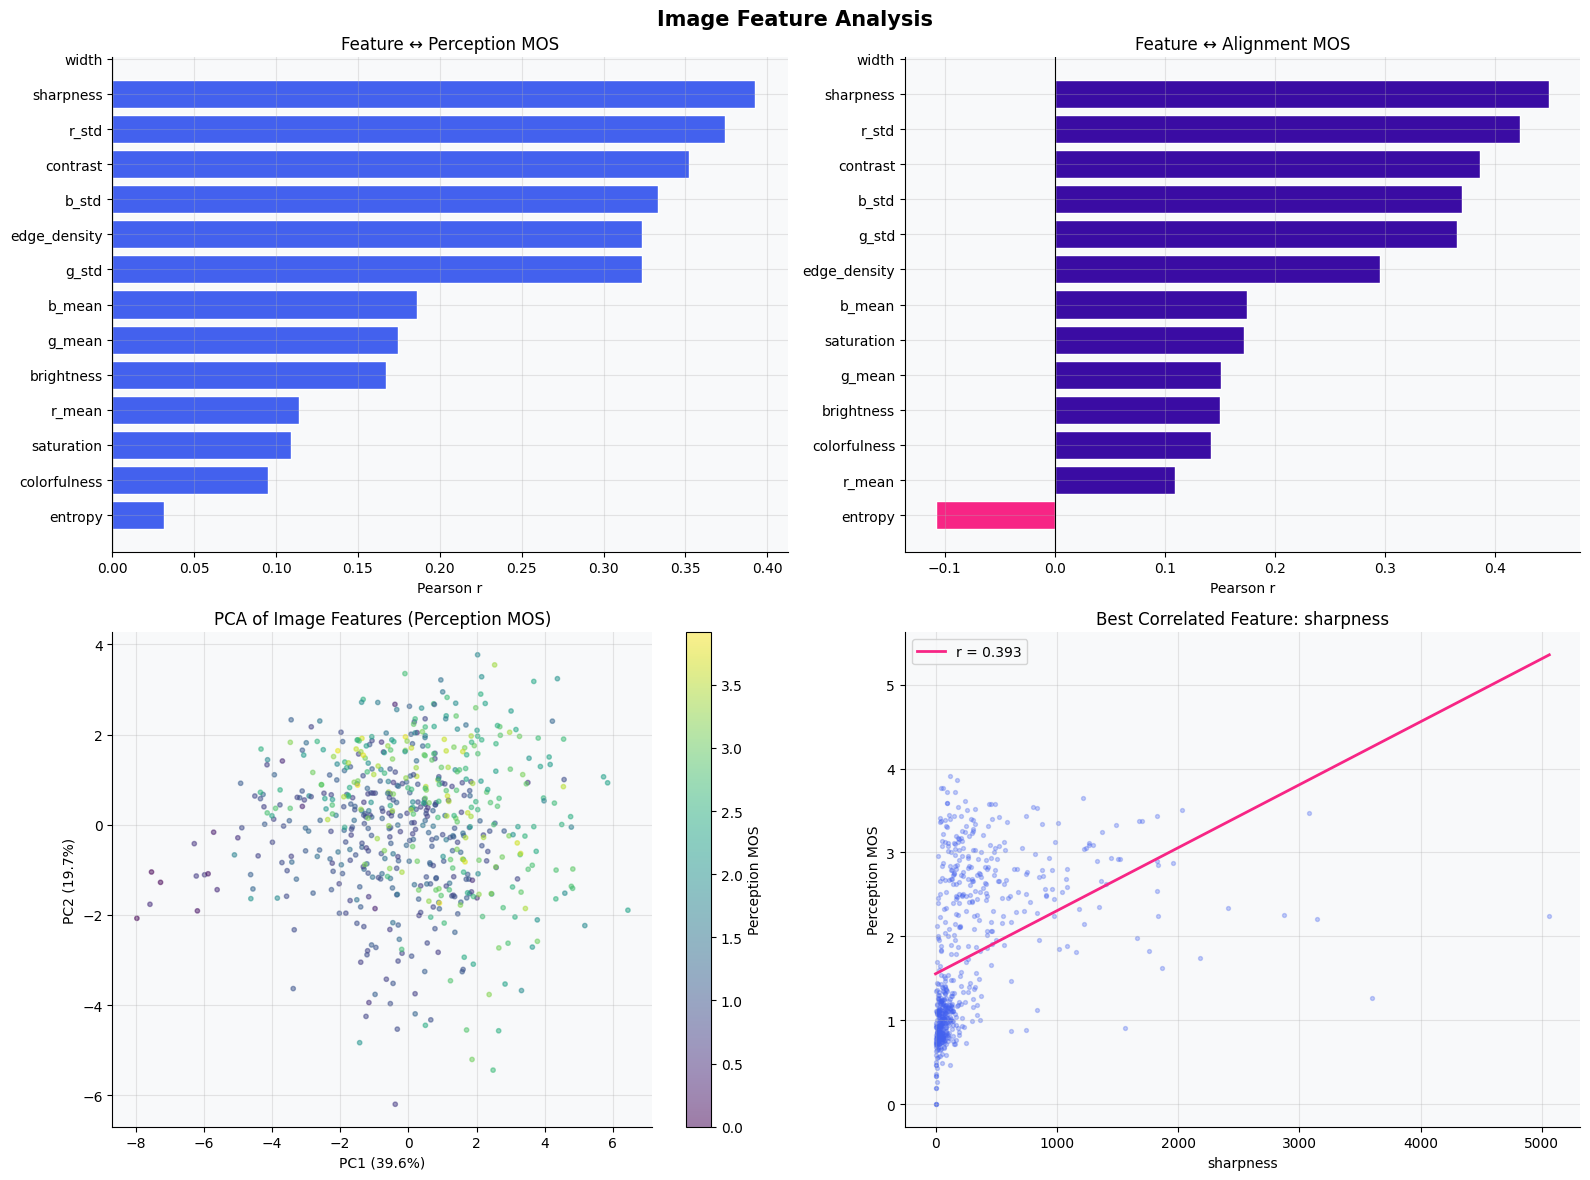

In [12]:
feat_cols = [c for c in FEATURE_NAMES if c in feat_df.columns]
merged = feat_df.copy()
merged['mos_p'] = df['mos_p'].reindex(merged.index)
merged['mos_a'] = df['mos_a'].reindex(merged.index)
merged = merged.dropna()
print(f'Merged shape for analysis: {merged.shape}')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Image Feature Analysis', fontsize=15, fontweight='bold')

# 9a — Correlation with perception
corr_p = merged[feat_cols].corrwith(merged['mos_p']).sort_values()
ax = axes[0, 0]
ax.barh(corr_p.index, corr_p.values,
        color=[PAL[1] if v < 0 else PAL[0] for v in corr_p.values], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r'); ax.set_title('Feature ↔ Perception MOS')

# 9b — Correlation with alignment
corr_a = merged[feat_cols].corrwith(merged['mos_a']).sort_values()
ax = axes[0, 1]
ax.barh(corr_a.index, corr_a.values,
        color=[PAL[1] if v < 0 else PAL[3] for v in corr_a.values], edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson r'); ax.set_title('Feature ↔ Alignment MOS')

# 9c — PCA (perception)
scaler = StandardScaler()
Xs = scaler.fit_transform(merged[feat_cols].fillna(0))
pca = PCA(n_components=2).fit(Xs)
coords = pca.transform(Xs)
ax = axes[1, 0]
sc = ax.scatter(coords[:,0], coords[:,1], c=merged['mos_p'], cmap='viridis', s=10, alpha=0.5)
plt.colorbar(sc, ax=ax, label='Perception MOS')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA of Image Features (Perception MOS)')

# 9d — Best feature scatter
top = corr_p.abs().idxmax()
ax = axes[1, 1]
ax.scatter(merged[top], merged['mos_p'], alpha=0.3, s=8, c=PAL[0])
r_val, _ = stats.pearsonr(merged[top], merged['mos_p'])
z = np.polyfit(merged[top], merged['mos_p'], 1)
xl = np.linspace(merged[top].min(), merged[top].max(), 100)
ax.plot(xl, np.polyval(z, xl), color=PAL[1], lw=2, label=f'r = {r_val:.3f}')
ax.set_xlabel(top); ax.set_ylabel('Perception MOS')
ax.set_title(f'Best Correlated Feature: {top}'); ax.legend()

plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig7_feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Preliminary ML Baselines (Hand-crafted Features)

> These results serve as a baseline before moving to CNN/ViT models. Metrics follow the proposal: **RMSE**, **PLCC (R²)**, **SRCC**.

In [14]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scaler2 = StandardScaler()
X = scaler2.fit_transform(merged[feat_cols].fillna(0))

ml_models = {
    'Ridge':             Ridge(alpha=1.0),
    'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = {}
for target, tlabel in [('mos_p','Perception'), ('mos_a','Alignment')]:
    y = merged[target].values
    for mname, model in ml_models.items():
        rmse = np.sqrt(-cross_val_score(model, X, y, cv=kf,
                                        scoring='neg_mean_squared_error')).mean()
        plcc = cross_val_score(model, X, y, cv=kf, scoring='r2').mean()
        sr_list = []
        for tr, vl in kf.split(X):
            model.fit(X[tr], y[tr])
            sr_list.append(stats.spearmanr(model.predict(X[vl]), y[vl])[0])
        key = f'{mname}\n({tlabel})'
        results[key] = {'RMSE': rmse, 'PLCC': plcc, 'SRCC': np.mean(sr_list)}
        print(f'{mname:20s} [{tlabel}]  RMSE={rmse:.4f}  PLCC={plcc:.4f}  SRCC={np.mean(sr_list):.4f}')

Ridge                [Perception]  RMSE=0.8404  PLCC=0.2144  SRCC=0.5195
Random Forest        [Perception]  RMSE=0.6424  PLCC=0.5392  SRCC=0.6888
Gradient Boosting    [Perception]  RMSE=0.6533  PLCC=0.5242  SRCC=0.6923
Ridge                [Alignment]  RMSE=0.9625  PLCC=0.3156  SRCC=0.5870
Random Forest        [Alignment]  RMSE=0.7152  PLCC=0.6216  SRCC=0.7253
Gradient Boosting    [Alignment]  RMSE=0.7244  PLCC=0.6127  SRCC=0.7140


In [15]:
# Results table
res_df = pd.DataFrame(results).T.round(4)
res_df

,RMSE,PLCC,SRCC
Ridge\n(Perception),0.8404,0.2144,0.5195
Random Forest\n(Perception),0.6424,0.5392,0.6888
Gradient Boosting\n(Perception),0.6533,0.5242,0.6923
Ridge\n(Alignment),0.9625,0.3156,0.5870
Random Forest\n(Alignment),0.7152,0.6216,0.7253
Gradient Boosting\n(Alignment),0.7244,0.6127,0.7140


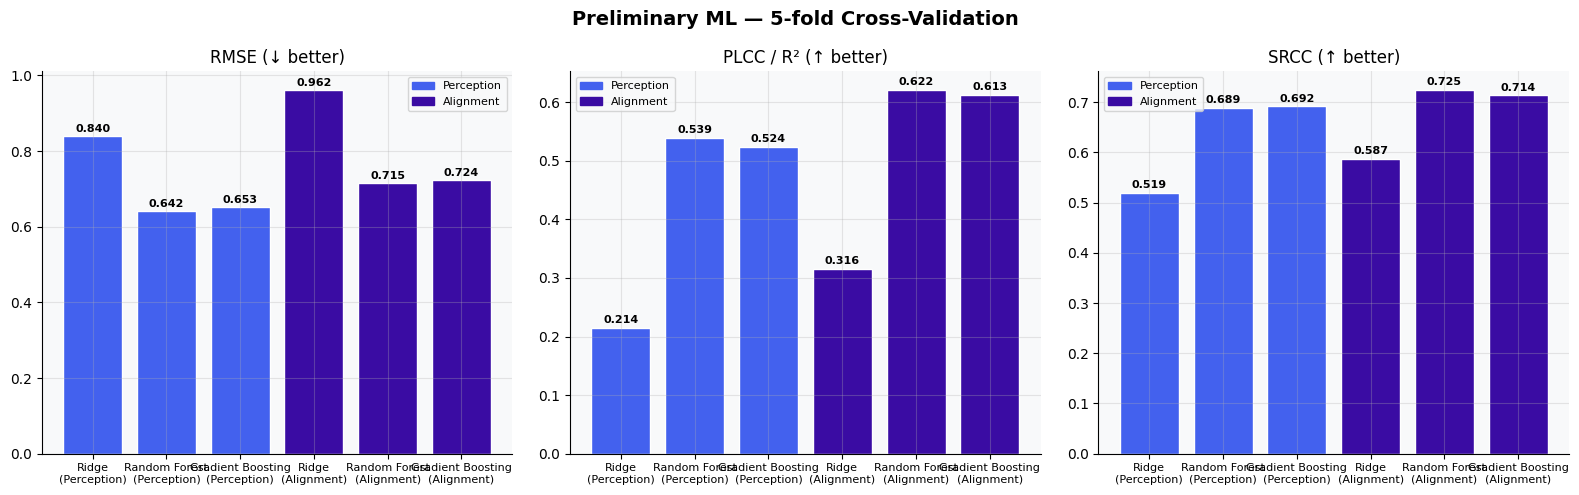

In [16]:
# Bar chart comparison
keys   = list(results.keys())
colors = [PAL[0] if 'Perception' in k else PAL[3] for k in keys]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Preliminary ML — 5-fold Cross-Validation', fontsize=14, fontweight='bold')

for ax, metric, title in zip(axes,
    ['RMSE', 'PLCC', 'SRCC'],
    ['RMSE (↓ better)', 'PLCC / R² (↑ better)', 'SRCC (↑ better)']):
    vals = [results[k][metric] for k in keys]
    bars = ax.bar(range(len(keys)), vals, color=colors, edgecolor='white')
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(keys)))
    ax.set_xticklabels(keys, fontsize=8)
    ax.set_title(title)
    ax.legend(handles=[Patch(color=PAL[0], label='Perception'),
                        Patch(color=PAL[3], label='Alignment')], fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig8_ml_results.png', dpi=150, bbox_inches='tight')
plt.show()

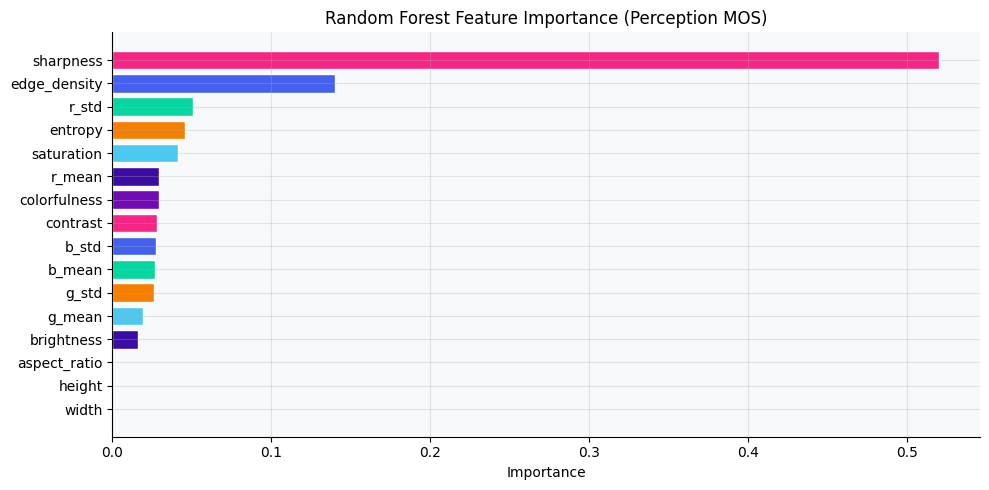

In [17]:
# Feature importance (Random Forest on perception)
rf_final = RandomForestRegressor(100, random_state=42, n_jobs=-1)
rf_final.fit(X, merged['mos_p'].values)
imp = pd.Series(rf_final.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(imp.index, imp.values,
        color=[PAL[i%len(PAL)] for i in range(len(imp))], edgecolor='white')
ax.set_xlabel('Importance')
ax.set_title('Random Forest Feature Importance (Perception MOS)')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}fig9_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Next Steps — Deep Learning Models

The EDA and baseline ML above are complete. The next notebook will cover:

1. **CNN Baseline** — ResNet-50 backbone + regression head, trained end-to-end on MOS
2. **Vision Transformer (ViT)** — pretrained ViT-B/16, fine-tuned for MOS regression
3. **Evaluation** — PLCC, SRCC, RMSE on held-out test set (70/15/15 split)
4. **Comparison** — proposed models vs NIQE / BRISQUE baselines
